In [66]:
!gdown 1u_lWZPAVIdWG2gsi5myYhdtMoJ3MP0_j

Downloading...
From: https://drive.google.com/uc?id=1u_lWZPAVIdWG2gsi5myYhdtMoJ3MP0_j
To: /content/twitter_sentiment_analysis_2cls_dataset.zip
100% 471k/471k [00:00<00:00, 102MB/s]


In [67]:
!unzip twitter_sentiment_analysis_2cls_dataset.zip

Archive:  twitter_sentiment_analysis_2cls_dataset.zip
replace sentiment_analysis.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: sentiment_analysis.csv  


In [68]:
# import lib
import re
import nltk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from nltk.tokenize import TweetTokenizer
from collections import defaultdict # mặc định gán giá trị cho các key mới là 0

# **1. Load Dataset**

In [111]:
dataset_path = 'sentiment_analysis.csv'
df = pd.read_csv(
    dataset_path,
    index_col = 'id'
)

In [112]:
df

,label,tweet
id,,
1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
2,0,Finally a transparant silicon case ^^ Thanks t...
3,0,We love this! Would you go? #talk #makememorie...
4,0,I'm wired I know I'm George I was made that wa...
5,1,What amazing service! Apple won't even talk to...
...,...,...
7916,0,Live out loud #lol #liveoutloud #selfie #smile...
7917,0,We would like to wish you an amazing day! Make...
7918,0,Helping my lovely 90 year old neighbor with he...


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7920 entries, 1 to 7920
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   7920 non-null   int64 
 1   tweet   7920 non-null   object
dtypes: int64(1), object(1)
memory usage: 185.6+ KB


In [114]:
# Xem tỷ lệ phần trăm của từng lớp
print("Tỷ lệ phân phối:")
print(df['label'].value_counts(normalize=True) * 100)

Tỷ lệ phân phối:
label
0    74.419192
1    25.580808
Name: proportion, dtype: float64


- Dataset is Slight Imbalance

/tmp/ipykernel_1553/4073395969.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Blues')


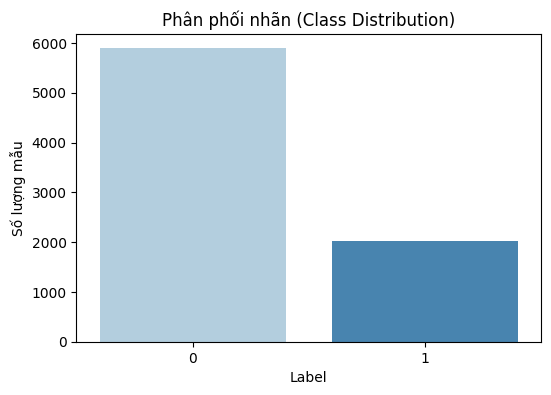

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette='Blues')
plt.title("Phân phối nhãn (Class Distribution)")
plt.xlabel("Label")
plt.ylabel("Số lượng mẫu")
plt.show()

# **2. Preprocessing data**

In [116]:
import re
from nltk.tokenize import TweetTokenizer

def preprocess_text(text):
    # Retweet old acronym "RT" removal
    text = re.sub(r'^RT [\s]+', '', text)

    # Hyperlinks removal
    text = re.sub(r'https?:\/\/.*[\ r\n]*', '', text)

    # Punctuation removal
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenization
    tokenizer = TweetTokenizer(
        preserve_case = False,  # Không giữ chữ in hoa -> chuyển chữ thường
        strip_handles = True,   # Loại bỏ các Twitter handeles, username bắt đầu bằng kí tự @
        reduce_len = True       # Giảm độ dài các chuỗi kí tự lặp liên tiếp
    )
    text_tokens = tokenizer.tokenize(text)
    return " ".join(text_tokens)

# Áp dụng tiền xử lý lên toàn bộ cột tweet
df['tweet'] = df['tweet'].apply(preprocess_text)

In [117]:
from sklearn.model_selection import train_test_split

val_size = 0.2
test_size = 0.125
random_state = 42

X = df['tweet']
y = df['label'].values

# Tách tập Val

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=val_size,
    random_state=random_state,
    stratify=y
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size=test_size,
    random_state=random_state,
    stratify=y_train
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 5544, Val: 1584, Test: 792


In [118]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=3000,      # Giới hạn 3000 đặc trưng phổ biến nhất để tránh overfitting và tối ưu tốc độ
    ngram_range=(1, 2),     # Xét từ đơn và cụm 2 từ liền kề để nắm bắt ngữ cảnh phủ định (vd: "not good")
    stop_words='english'
)

X_train = tfidf.fit_transform(X_train)
X_val = tfidf.transform(X_val)
X_test = tfidf.transform(X_test)

print("Kích thước ma trận TF-IDF tập Train:", X_train.shape)

Kích thước ma trận TF-IDF tập Train: (5544, 3000)


# **3. Modeling**

In [119]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [120]:
log_reg = LogisticRegression(
    solver='liblinear',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

In [121]:
y_pred_train = log_reg.predict(X_train)
y_pred_val = log_reg.predict(X_val)
y_pred_test = log_reg.predict(X_test)

In [122]:
acc_test = accuracy_score(y_test, y_pred_test)
acc_val = accuracy_score(y_val, y_pred_val)
acc_train = accuracy_score(y_train, y_pred_train)

print(f"Accuracy for Train set: {acc_train}")
print(f"Accuracy for Validation set: {acc_val}")
print(f"Accuracy for Test set: {acc_test}")

Accuracy for Train set: 0.9146825396825397
Accuracy for Validation set: 0.8800505050505051
Accuracy for Test set: 0.8611111111111112


In [123]:
print("--- Test Classification Report ---")
print(classification_report(y_test, y_pred_test))

--- Test Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.85      0.90       589
           1       0.68      0.88      0.76       203

    accuracy                           0.86       792
   macro avg       0.81      0.87      0.83       792
weighted avg       0.88      0.86      0.87       792



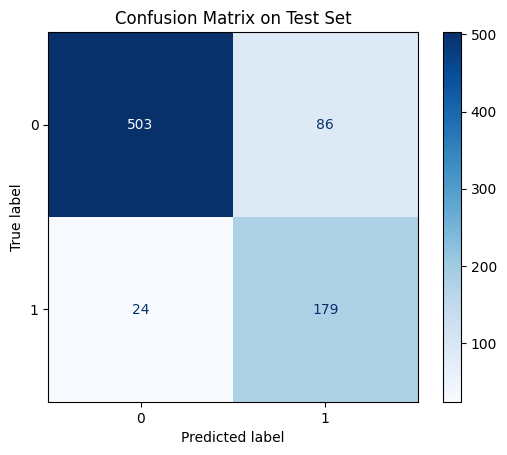

In [124]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix on Test Set")
plt.show()